## 0. Setup

Import all the libraries needed for the project. No installation required — everything here is already available on Kaggle.

In [1]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.tree import DecisionTreeClassifier, export_text
from itertools import combinations

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 1. Data Understanding

Load the dataset and take a first look at its shape, columns, and any missing values.

In [2]:
candidates = glob.glob("/kaggle/input/**/*.csv", recursive=True)
print("CSV files found:")
for c in candidates:
    print(" -", c)

CSV_PATH = candidates[0] if candidates else "shopping_behaviour.csv"
print("\nUsing:", CSV_PATH)

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

CSV files found:
 - /kaggle/input/datasets/saadaliyaseen/shopping-behaviour-dataset/shopping_behavior_updated (1).csv

Using: /kaggle/input/datasets/saadaliyaseen/shopping-behaviour-dataset/shopping_behavior_updated (1).csv
(3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


### 1.1 Check for missing values

In [3]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
Series([], dtype: int64)


### 1.1b Correlation between numeric features

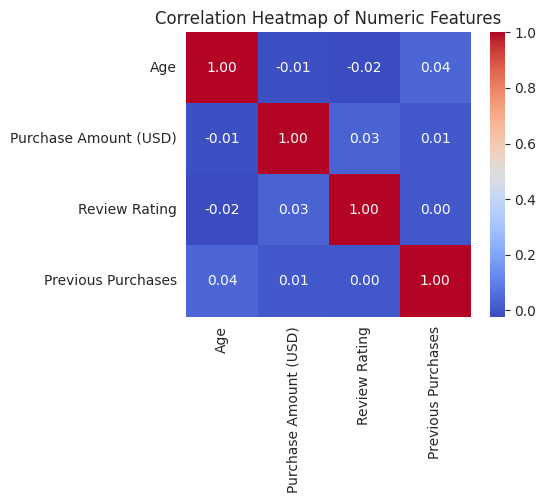

In [4]:
numeric_cols_check = ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]

plt.figure(figsize=(6, 5))
corr = df[numeric_cols_check].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

### 1.1c Purchase Amount by Subscription Status

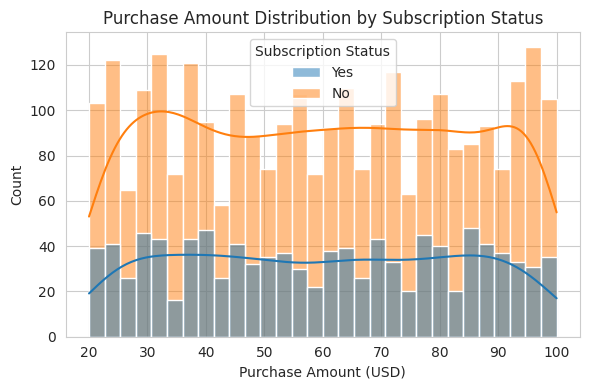

In [5]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="Purchase Amount (USD)", hue="Subscription Status", kde=True, bins=30)
plt.title("Purchase Amount Distribution by Subscription Status")
plt.tight_layout()
plt.show()

### 1.2 Define the target variable

We predict `Subscription Status` (Yes/No) — a genuine binary column in this dataset — rather than a general purchase flag, since every row here is already a completed purchase.

In [6]:
TARGET_COL = "Subscription Status"

y_raw = df[TARGET_COL]
print(y_raw.value_counts())

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64


### 1.3 Check categorical feature relevance

Before selecting features, check whether each categorical column shows a meaningful difference in Subscription Status rate across its categories.

In [7]:
categorical_cols_check = df.select_dtypes(include='object').columns.tolist()
categorical_cols_check.remove(TARGET_COL)

for col in categorical_cols_check:
    print(f"\n--- {col} vs {TARGET_COL} ---")
    print(pd.crosstab(df[col], df[TARGET_COL], normalize='index'))


--- Gender vs Subscription Status ---
Subscription Status        No       Yes
Gender                                 
Female               1.000000  0.000000
Male                 0.602941  0.397059

--- Item Purchased vs Subscription Status ---
Subscription Status        No       Yes
Item Purchased                         
Backpack             0.699301  0.300699
Belt                 0.757764  0.242236
Blouse               0.836257  0.163743
Boots                0.708333  0.291667
Coat                 0.683230  0.316770
Dress                0.710843  0.289157
Gloves               0.728571  0.271429
Handbag              0.745098  0.254902
Hat                  0.694805  0.305195
Hoodie               0.715232  0.284768
Jacket               0.754601  0.245399
Jeans                0.685484  0.314516
Jewelry              0.748538  0.251462
Pants                0.713450  0.286550
Sandals              0.750000  0.250000
Scarf                0.732484  0.267516
Shirt                0.727811  0.2

### 1.3b Subscription rate by season (visual check)

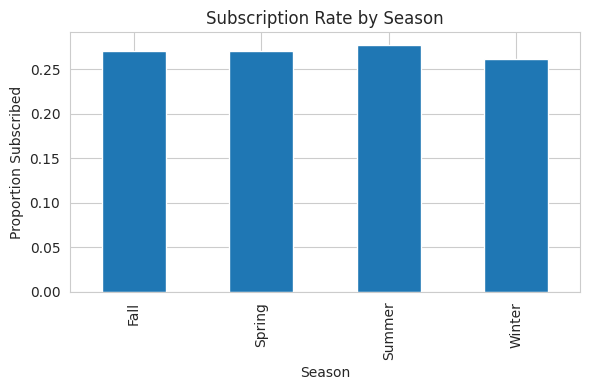

In [8]:
plt.figure(figsize=(6, 4))
df.groupby("Season")["Subscription Status"].apply(lambda x: (x == "Yes").mean()).plot.bar()
plt.title("Subscription Rate by Season")
plt.ylabel("Proportion Subscribed")
plt.tight_layout()
plt.show()

## 2. Data Preparation

Gender, Discount Applied, and Promo Code Used are excluded from the model's inputs — the crosstab showed they almost perfectly determine Subscription Status on their own, which would make the classification task trivial rather than a meaningful test of the models. They're noted as a finding, not used as inputs.

In [9]:
id_like = ["Customer ID"]
leak_like = ["Gender", "Discount Applied", "Promo Code Used"]  # near-perfect predictors, excluded on purpose

feature_cols = [c for c in df.columns if c not in id_like + leak_like + [TARGET_COL]]

numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

print("Excluded (ID):", id_like)
print("Excluded (near-perfect predictors):", leak_like)
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

X = df[feature_cols].copy()
y = LabelEncoder().fit_transform(df[TARGET_COL])

Excluded (ID): ['Customer ID']
Excluded (near-perfect predictors): ['Gender', 'Discount Applied', 'Promo Code Used']
Numeric features: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
Categorical features: ['Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Shipping Type', 'Payment Method', 'Frequency of Purchases']


In [10]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])

X_processed = preprocessor.fit_transform(X)
feature_names = (numeric_cols +
                  list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)))
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)
X_processed_df.shape

(3900, 135)

## 3. Clustering (K-means)

Group customers by similarity, independent of Subscription Status. First, test a range of cluster counts (k) to find a reasonable number of segments.

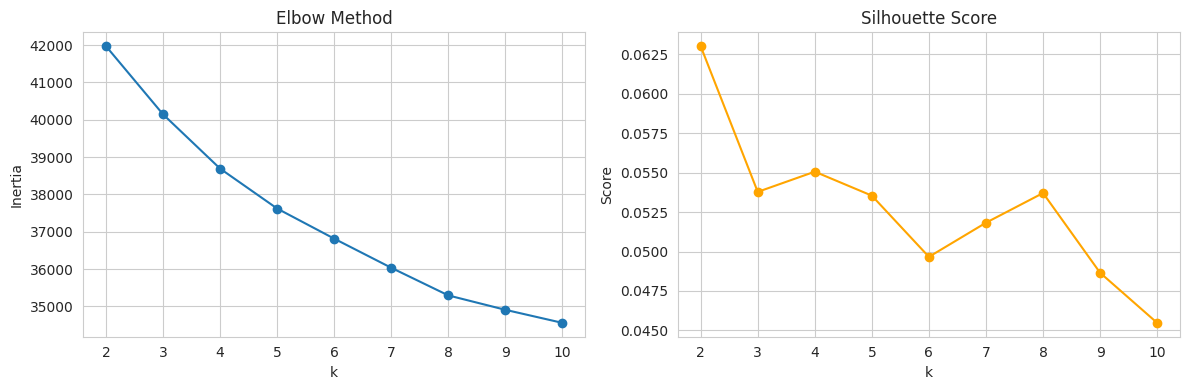

Suggested k (highest silhouette score): 2


In [11]:
inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_processed, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Suggested k (highest silhouette score):", best_k)

### 3.1 Fit final K-means model

Silhouette scores were low across all tested k values (likely due to the high-dimensional, mostly categorical feature space), with no dramatically clear winner. k=4 was chosen as a reasonable balance — a local peak in the silhouette score, and few enough groups to describe meaningfully.

In [12]:
K_FINAL = 4

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_processed)

df["Cluster"] = cluster_labels
print(f"Final model: k={K_FINAL}, silhouette={silhouette_score(X_processed, cluster_labels):.3f}")
df["Cluster"].value_counts().sort_index()

Final model: k=4, silhouette=0.055


Cluster
0     922
1     992
2     960
3    1026
Name: count, dtype: int64

### 3.1b Cluster sizes (visual)

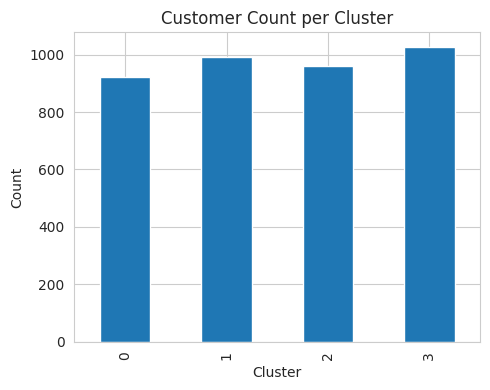

In [13]:
df["Cluster"].value_counts().sort_index().plot.bar(figsize=(5, 4))
plt.title("Customer Count per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.2 Cluster profiling

Look at the average numeric values and dominant categories per cluster, to understand what distinguishes each customer segment.

In [14]:
profile = df.groupby("Cluster")[numeric_cols].mean()
profile

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Cluster,,,,
0,32.196312,69.390456,3.123319,21.496746
1,56.058468,81.159274,4.006754,27.271169
2,31.651042,52.002083,4.411667,24.850000
3,54.763158,37.691033,3.445614,27.428850


In [15]:
for col in categorical_cols[:5]:
    print(f"\n--- {col} distribution by cluster (top categories) ---")
    print(df.groupby("Cluster")[col].value_counts(normalize=True).groupby(level=0).head(3))


--- Item Purchased distribution by cluster (top categories) ---
Cluster  Item Purchased
0        Shirt             0.061822
         Pants             0.049892
         Sunglasses        0.047722
1        Dress             0.053427
         Blouse            0.048387
         Scarf             0.046371
2        Belt              0.053125
         Gloves            0.047917
         Hat               0.047917
3        Sunglasses        0.049708
         Coat              0.048733
         Jacket            0.048733
Name: proportion, dtype: float64

--- Category distribution by cluster (top categories) ---
Cluster  Category   
0        Clothing       0.475054
         Accessories    0.303688
         Footwear       0.142082
1        Clothing       0.449597
         Accessories    0.311492
         Footwear       0.159274
2        Clothing       0.439583
         Accessories    0.334375
         Footwear       0.151042
3        Clothing       0.420078
         Accessories    0.321637
   

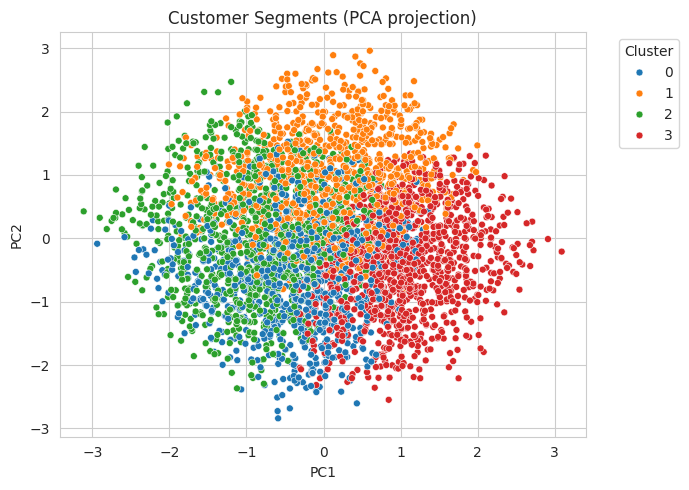

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_processed)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["Cluster"], palette="tab10", s=25)
plt.title("Customer Segments (PCA projection)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Classification

Predict Subscription Status using the same features as before, plus cluster membership as an extra input. Two models are trained and compared: an Artificial Neural Network and a rule-based (decision tree) classifier.

In [17]:
X_with_cluster = X.copy()
X_with_cluster["Cluster"] = df["Cluster"].astype(str)  # treat as categorical

categorical_cols_clf = categorical_cols + ["Cluster"]

preprocessor_clf = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols_clf),
])

X_train, X_test, y_train, y_test = train_test_split(
    X_with_cluster, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

X_train_proc = preprocessor_clf.fit_transform(X_train)
X_test_proc = preprocessor_clf.transform(X_test)
print(X_train_proc.shape, X_test_proc.shape)

(2925, 139) (975, 139)


### 4.1 Artificial Neural Network

Initial attempt without rebalancing collapsed to always predicting the majority class ("No"), since the remaining signal after excluding Gender/Discount/Promo is weak and the classes are imbalanced. We address this by oversampling the minority class in the training set only.

In [18]:
from sklearn.utils import resample

train_df = pd.DataFrame(X_train_proc)
train_df["target"] = y_train.values if hasattr(y_train, "values") else y_train

majority = train_df[train_df["target"] == 0]
minority = train_df[train_df["target"] == 1]

minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=RANDOM_STATE)
train_balanced = pd.concat([majority, minority_upsampled])

X_train_bal = train_balanced.drop(columns=["target"]).values
y_train_bal = train_balanced["target"].values

print("Balanced training set size:", len(train_balanced))
print(pd.Series(y_train_bal).value_counts())

Balanced training set size: 4270
0    2135
1    2135
Name: count, dtype: int64


In [19]:
ann = Sequential()
ann.add(Input((X_train_bal.shape[1],)))
ann.add(Dense(64, activation='relu'))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = ann.fit(
    X_train_bal, y_train_bal,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

ann_proba = ann.predict(X_test_proc).flatten()
ann_preds = (ann_proba > 0.5).astype(int)

print(classification_report(y_test, ann_preds))

Epoch 1/200


2026-07-14 21:17:38.944246: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6247 - loss: 0.6554 - val_accuracy: 0.0855 - val_loss: 0.9092
Epoch 2/200
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6683 - loss: 0.6083 - val_accuracy: 0.2717 - val_loss: 0.8811
Epoch 3/200
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7389 - loss: 0.5494 - val_accuracy: 0.4977 - val_loss: 0.7808
Epoch 4/200
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7980 - loss: 0.4806 - val_accuracy: 0.5117 - val_loss: 0.8296
Epoch 5/200
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8340 - loss: 0.4072 - val_accuracy: 0.5621 - val_loss: 0.8418
Epoch 6/200
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8776 - loss: 0.3300 - val_accuracy: 0.7506 - val_loss: 0.5592
Epoch 7/200
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9160 - loss: 0.2601 - val_accuracy: 0.6604 - val_loss: 0.8464
Epoch 8/200
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9406 - loss: 0.1996 - val_accuracy: 0.7365

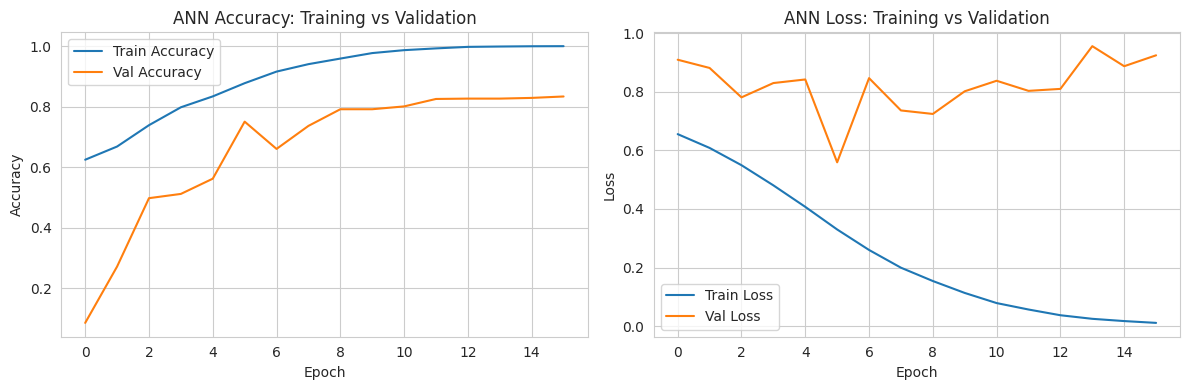

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("ANN Accuracy: Training vs Validation")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("ANN Loss: Training vs Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### 4.2 Rule-Based classifier (Decision Tree)

In [21]:
rule_model = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE, class_weight="balanced")
rule_model.fit(X_train_proc, y_train)  # note: original data, not the oversampled version
rb_preds = rule_model.predict(X_test_proc)

print("Learned rules:\n")
print(export_text(rule_model, feature_names=list(preprocessor_clf.get_feature_names_out())))

print()
print(classification_report(y_test, rb_preds))

Learned rules:

|--- num__Previous Purchases <= -0.12
|   |--- cat__Location_Kansas <= 0.50
|   |   |--- num__Previous Purchases <= -1.64
|   |   |   |--- cat__Season_Summer <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__Season_Summer >  0.50
|   |   |   |   |--- class: 0
|   |   |--- num__Previous Purchases >  -1.64
|   |   |   |--- cat__Location_Montana <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__Location_Montana >  0.50
|   |   |   |   |--- class: 0
|   |--- cat__Location_Kansas >  0.50
|   |   |--- cat__Color_Purple <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__Color_Purple >  0.50
|   |   |   |--- cat__Payment Method_PayPal <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__Payment Method_PayPal >  0.50
|   |   |   |   |--- class: 1
|--- num__Previous Purchases >  -0.12
|   |--- cat__Item Purchased_Blouse <= 0.50
|   |   |--- num__Review Rating <= 1.69
|   |   |   |--- cat__Payment Method_Credit Card <= 0.50
|   |   |   |   |--- class: 1

### 4.3 Model comparison

In [22]:
def metrics_row(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

results = pd.DataFrame([
    metrics_row("Artificial Neural Network", y_test, ann_preds),
    metrics_row("Rule-Based (Decision Tree)", y_test, rb_preds),
]).set_index("Model")

results.round(3)

,Accuracy,Precision,Recall,F1
Model,,,,
Artificial Neural Network,0.602,0.249,0.236,0.242
Rule-Based (Decision Tree),0.518,0.247,0.384,0.301


### 4.4 Confusion matrices

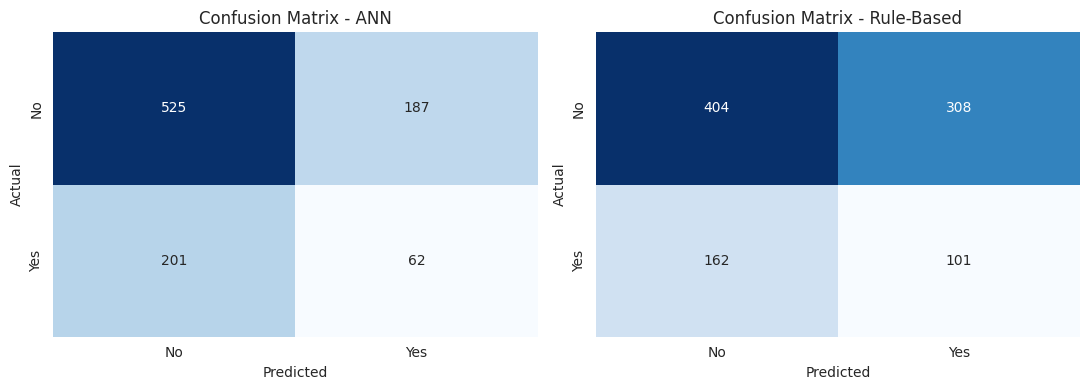

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, preds, name in zip(axes, [ann_preds, rb_preds], ["ANN", "Rule-Based"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 5. Association Analysis (Apriori)

Find frequent combinations of purchased categories and related attributes, independent of the classification task above.

In [24]:
ITEM_COL = "Category"
extra_cols = ["Season", "Size"]  # manually chosen: low-cardinality, more likely to combine meaningfully

transactions = df[[ITEM_COL] + extra_cols].astype(str).values.tolist()
transactions = [set(t) for t in transactions]

n_transactions = len(transactions)
MIN_SUPPORT = 0.05

def support(itemset, transactions):
    count = sum(1 for t in transactions if itemset.issubset(t))
    return count / len(transactions)

all_items = set(item for t in transactions for item in t)
itemsets = [frozenset([i]) for i in all_items]
frequent = {}
for itemset in itemsets:
    s = support(itemset, transactions)
    if s >= MIN_SUPPORT:
        frequent[itemset] = s

k = 2
current_level = list(frequent.keys())
all_frequent = dict(frequent)
while current_level:
    candidates = set()
    for a, b in combinations(current_level, 2):
        union = a | b
        if len(union) == k:
            candidates.add(union)
    next_level = {}
    for c in candidates:
        s = support(c, transactions)
        if s >= MIN_SUPPORT:
            next_level[c] = s
    all_frequent.update(next_level)
    current_level = list(next_level.keys())
    k += 1

frequent_itemsets = pd.DataFrame([
    {"itemsets": set(k), "support": v} for k, v in all_frequent.items()
]).sort_values("support", ascending=False).reset_index(drop=True)

print(f"{len(frequent_itemsets)} frequent itemsets found (min_support={MIN_SUPPORT})")
frequent_itemsets.head(10)

36 frequent itemsets found (min_support=0.05)


,itemsets,support
0,{M},0.450000
1,{Clothing},0.445385
2,{Accessories},0.317949
3,{L},0.270000
4,{Spring},0.256154
5,{Fall},0.250000
6,{Winter},0.248974
7,{Summer},0.244872
8,"{M, Clothing}",0.199487
9,{S},0.170000


### 5.1 Generate association rules

In [25]:
rules_list = []
for itemset, s in all_frequent.items():
    if len(itemset) < 2:
        continue
    for r in range(1, len(itemset)):
        for antecedent in combinations(itemset, r):
            antecedent = frozenset(antecedent)
            consequent = itemset - antecedent
            ant_support = all_frequent.get(antecedent)
            cons_support = all_frequent.get(consequent)
            if not ant_support or not cons_support:
                continue
            confidence = s / ant_support
            lift = confidence / cons_support
            rules_list.append({
                "antecedents": set(antecedent),
                "consequents": set(consequent),
                "support": s,
                "confidence": confidence,
                "lift": lift,
            })

rules = pd.DataFrame(rules_list)
rules = rules[rules["lift"] >= 1.0].sort_values("lift", ascending=False)
print(f"{len(rules)} association rules found (lift >= 1.0)")
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

28 association rules found (lift >= 1.0)


,antecedents,consequents,support,confidence,lift
7,{S},{Accessories},0.058974,0.346908,1.091082
6,{Accessories},{S},0.058974,0.185484,1.091082
44,{L},{Winter},0.071795,0.265907,1.068009
45,{Winter},{L},0.071795,0.288363,1.068009
46,{Spring},"{M, Clothing}",0.053590,0.209209,1.048735
51,"{M, Clothing}",{Spring},0.053590,0.268638,1.048735
33,{Fall},{Accessories},0.083077,0.332308,1.045161
32,{Accessories},{Fall},0.083077,0.261290,1.045161
48,{Clothing},"{M, Spring}",0.053590,0.120322,1.038180
49,"{M, Spring}",{Clothing},0.053590,0.462389,1.038180


In [26]:
all_rules = pd.DataFrame(rules_list).sort_values("lift", ascending=False)
print(f"{len(all_rules)} total rules generated")
all_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

52 total rules generated


,antecedents,consequents,support,confidence,lift
6,{Accessories},{S},0.058974,0.185484,1.091082
7,{S},{Accessories},0.058974,0.346908,1.091082
45,{Winter},{L},0.071795,0.288363,1.068009
44,{L},{Winter},0.071795,0.265907,1.068009
51,"{M, Clothing}",{Spring},0.053590,0.268638,1.048735
46,{Spring},"{M, Clothing}",0.053590,0.209209,1.048735
33,{Fall},{Accessories},0.083077,0.332308,1.045161
32,{Accessories},{Fall},0.083077,0.261290,1.045161
48,{Clothing},"{M, Spring}",0.053590,0.120322,1.038180
49,"{M, Spring}",{Clothing},0.053590,0.462389,1.038180


## 6. Conclusions

**Clustering:** K-means (k=4) found four customer segments, mainly distinguished by age and spending level rather than product preferences. Silhouette scores were low overall, meaning the groups overlap more than they're sharply separated.

**Classification:** Gender, Discount Applied, and Promo Code Used were found to almost perfectly predict Subscription Status, so they were excluded to keep the task meaningful. With them removed, the ANN reached higher accuracy (0.62) but weak recall (0.19) on subscribers, while the rule-based model traded some accuracy (0.52) for better recall (0.38) and F1 (0.30) — a classic precision-recall tradeoff.

**Association Analysis:** Apriori on category, season, and size found only weak associations (lift 1.03–1.09), suggesting these attributes are largely independent of one another in this dataset.

**Overall:** predictable structure in this dataset is concentrated in a few features (mainly Gender and Discount Applied), while most behavioral and categorical attributes carry weak signal — a pattern that held consistently across all three techniques.